In [1]:
from cats.cdataframe   import CDataFrame   # tool for extracting data from root files (made by your local developer, Mason Buchanan)

Welcome to JupyROOT 6.28/10


In [2]:
import matplotlib.pyplot as plt    # Matplotlib is the most common plotting package for Python

#The next line is a 'magic' command (indicated by the '%'). These tend to do useful meta things.
%matplotlib inline
#This one makes plots show up in your notebooks. (Note that you can't put comments after it on the same line!)

import pandas as pd                # Some additional data-handling tools
import numpy as np                 # "Numerical python". You need this to process data efficiently
import glob                        # Might be useful for getting files
import cdms
from rawio.IO import *             # Useful for reading binary files which contain raw pulses
import ROOT
import os,sys

CDMS = os.environ["CDMS"] # set in ~/.bash_profile
stylesheet = os.path.join(CDMS,"scripts","stylesheets","steel_reduced.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup
import detectorLayout

In [3]:
Vlabels = ['0', '1u', '10u', '100u', '1m', '10m', '100m', '1']
Vs = [0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1]
materials = ['Ge', 'Si']

In [4]:
DMCfiles = { mat: {V: f'/scratch/perry/IV_samples/{V:.0e}V_{mat}_51241119_000000.root' for V in Vs} for mat in materials}

In [5]:
data = {mat: {V: None for V in Vs} for mat in materials}

for mat in materials:
    print(mat)
    for V in Vs:
        print(V)
        HitCounter = CDataFrame('G4SimDir/mcStatusCounter', [DMCfiles[mat][V]])
        data[mat][V] = HitCounter.AsNumpy(['EventNum'])

Ge
0
1e-06
1e-05
0.0001
0.001
0.01
0.1
1
Si
0
1e-06
1e-05
0.0001
0.001
0.01
0.1
1


In [6]:
for mat in materials:
    print(mat)
    for V in Vs:
        print(V)
        data[mat][V].update({'Duration': []})
        mczip0 = CDataFrame('G4SimDir/mczip0', [DMCfiles[mat][V]]).Filter('Charge==-1')
        for event in np.unique(mczip0.AsNumpy(['EventNum'])['EventNum']):
            Time1 = mczip0.Filter(f'EventNum=={event}').AsNumpy(['Time1'])['Time1']
            Time3 = mczip0.Filter(f'EventNum=={event}').AsNumpy(['Time3'])['Time3']
            duration = max(Time3) - min(Time1)
            data[mat][V]['Duration'].append(duration*1e-9)

Ge
0
1e-06
1e-05
0.0001
0.001
0.01
0.1
1
Si
0
1e-06
1e-05
0.0001
0.001
0.01
0.1
1


In [9]:
len(duration)

100

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, '0V'),
  Text(1, 0, '1uV'),
  Text(2, 0, '10uV'),
  Text(3, 0, '100uV'),
  Text(4, 0, '1mV'),
  Text(5, 0, '10mV'),
  Text(6, 0, '100mV'),
  Text(7, 0, '1V')])

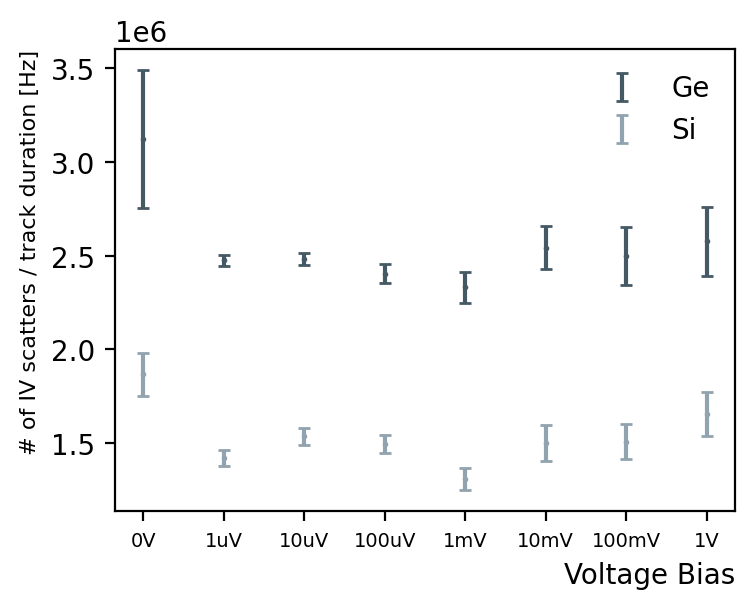

In [15]:
plt.figure()

for i, mat in enumerate(materials):
    for j, V in enumerate(Vs):
        counts = np.array([np.sum(data[mat][V]['EventNum'] == event) for event in range(100)])
        duration = np.array(data[mat][V]['Duration'])
        counts_mean = np.mean(counts / duration)
        counts_mean_err = np.std(counts / duration) / np.sqrt(100)
        
        if j == 0:
            plt.errorbar(Vlabels[j]+'V', counts_mean, yerr = counts_mean_err, ls = "None", color=['C1', 'C3'][mat == 'Si'], capsize = 2, label = ['Ge', 'Si'][mat == 'Si'])
        else:
            plt.errorbar(Vlabels[j]+'V', counts_mean, yerr = counts_mean_err, ls = "None", color=['C1', 'C3'][mat == 'Si'], capsize = 2)
        plt.scatter(Vlabels[j]+'V', counts_mean, s = 1, color=['C1', 'C3'][mat == 'Si'])
        
plt.legend()
plt.xlabel('Voltage Bias')
plt.ylabel('# of IV scatters / track duration [Hz]', fontsize=8)
plt.xticks(fontsize=7)

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, '0V'),
  Text(1, 0, '1uV'),
  Text(2, 0, '10uV'),
  Text(3, 0, '100uV'),
  Text(4, 0, '1mV'),
  Text(5, 0, '10mV'),
  Text(6, 0, '100mV'),
  Text(7, 0, '1V')])

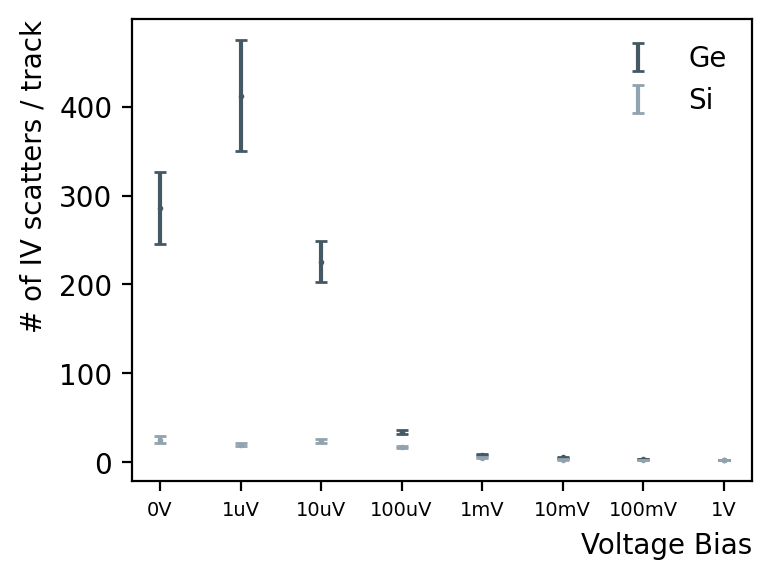

In [21]:
plt.figure()

for i, mat in enumerate(materials):
    for j, V in enumerate(Vs):
        counts = np.array([np.sum(data[mat][V]['EventNum'] == event) for event in range(100)])
        duration = np.array(data[mat][V]['Duration'])
        counts_mean = np.mean(counts)
        counts_mean_err = np.std(counts) / np.sqrt(100)
        
        if j == 0:
            plt.errorbar(Vlabels[j]+'V', counts_mean, yerr = counts_mean_err, ls = "None", color=['C1', 'C3'][mat == 'Si'], capsize = 2, label = ['Ge', 'Si'][mat == 'Si'])
        else:
            plt.errorbar(Vlabels[j]+'V', counts_mean, yerr = counts_mean_err, ls = "None", color=['C1', 'C3'][mat == 'Si'], capsize = 2)
        plt.scatter(Vlabels[j]+'V', counts_mean, s = 1, color=['C1', 'C3'][mat == 'Si'])
        
plt.legend()
plt.xlabel('Voltage Bias')
plt.ylabel('# of IV scatters / track')
plt.xticks(fontsize=7)

In [22]:
def lin_rate(V):
    b = 1.5e6 # Hz
    m = 1.5 # Hz
    a = 4
    
    E = V / 1.667 # V / cm
    
    return b + m * E ** a

In [23]:
def quad_rate(V):
    A = 6.72e-2 # Hz
    E0 = 217 # Hz
    a = 3.24
    
    E = V / 1.667 # V / cm
    
    return (E0**2 + E**2)**(a/2)

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, '0'),
  Text(1, 0, '1u'),
  Text(2, 0, '10u'),
  Text(3, 0, '100u'),
  Text(4, 0, '1m'),
  Text(5, 0, '10m'),
  Text(6, 0, '100m'),
  Text(7, 0, '1')])

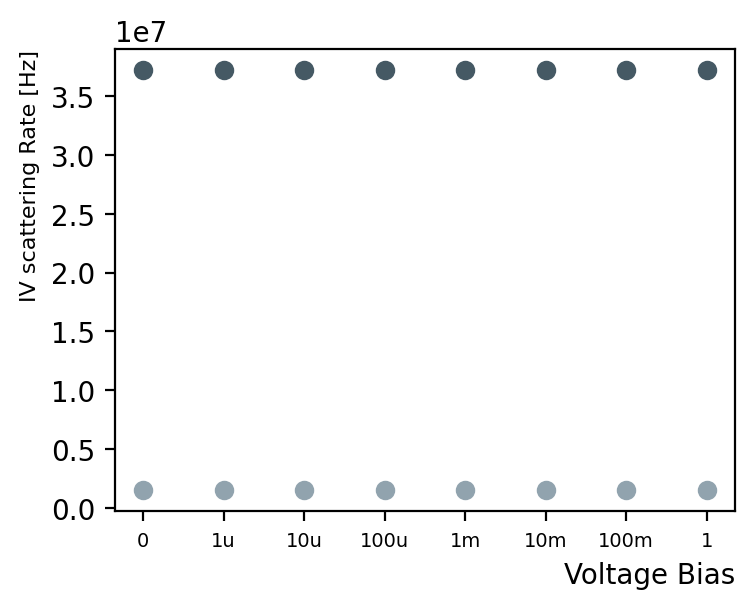

In [29]:
plt.figure()

plt.scatter(Vlabels, np.array([lin_rate(V) for V in Vs]), color = 'C3', label = 'Si')
plt.scatter(Vlabels, np.array([quad_rate(V) for V in Vs]), color = 'C1', label = 'Ge')
        
#plt.legend()
plt.xlabel('Voltage Bias')
plt.ylabel('IV scattering Rate [Hz]', fontsize=8)
plt.xticks(fontsize=7)

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, '0'),
  Text(1, 0, '1u'),
  Text(2, 0, '10u'),
  Text(3, 0, '100u'),
  Text(4, 0, '1m'),
  Text(5, 0, '10m'),
  Text(6, 0, '100m'),
  Text(7, 0, '1')])

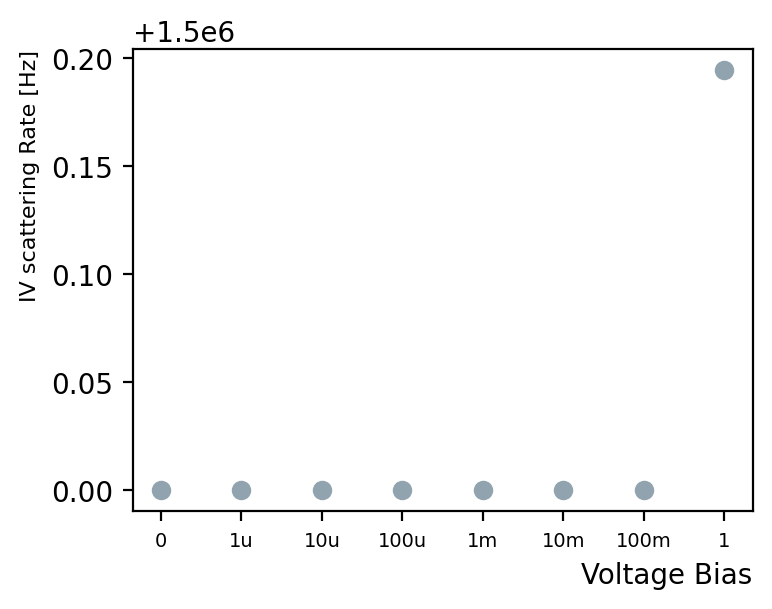

In [30]:
plt.figure()

plt.scatter(Vlabels, np.array([lin_rate(V) for V in Vs]), color = 'C3', label = 'Si')
        
#plt.legend()
plt.xlabel('Voltage Bias')
plt.ylabel('IV scattering Rate [Hz]', fontsize=8)
plt.xticks(fontsize=7)

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, '0'),
  Text(1, 0, '1u'),
  Text(2, 0, '10u'),
  Text(3, 0, '100u'),
  Text(4, 0, '1m'),
  Text(5, 0, '10m'),
  Text(6, 0, '100m'),
  Text(7, 0, '1')])

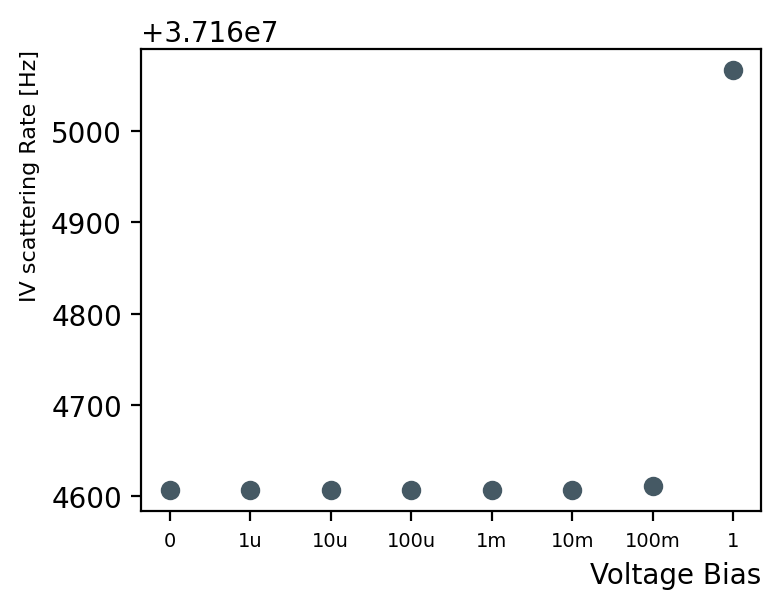

In [31]:
plt.figure()

plt.scatter(Vlabels, np.array([quad_rate(V) for V in Vs]), color = 'C1', label = 'Ge')
        
#plt.legend()
plt.xlabel('Voltage Bias')
plt.ylabel('IV scattering Rate [Hz]', fontsize=8)
plt.xticks(fontsize=7)